# Data Understanding

In [13]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the meta data

In [14]:
df = pd.read_csv('../datasets/raw/meta/esc50.csv')
df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [15]:
df.shape

(2000, 7)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2000 non-null   object
 1   fold      2000 non-null   int64 
 2   target    2000 non-null   int64 
 3   category  2000 non-null   object
 4   esc10     2000 non-null   bool  
 5   src_file  2000 non-null   int64 
 6   take      2000 non-null   object
dtypes: bool(1), int64(3), object(3)
memory usage: 95.8+ KB


In [17]:
df

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A
...,...,...,...,...,...,...,...
1995,5-263831-B-6.wav,5,6,hen,False,263831,B
1996,5-263902-A-36.wav,5,36,vacuum_cleaner,False,263902,A
1997,5-51149-A-25.wav,5,25,footsteps,False,51149,A
1998,5-61635-A-8.wav,5,8,sheep,False,61635,A


There are two columns that are required for us.
- filename # which will have the name of file in audio folder.
- category # which will have what kind of noise is that. 

category column is used to split the data into wildlife and threat.

NB: Some irrelavent datas are also present in the dataset that we will not take up.

In [18]:
df = df[['filename','category']]

In [19]:
df.head()

,filename,category
0,1-100032-A-0.wav,dog
1,1-100038-A-14.wav,chirping_birds
2,1-100210-A-36.wav,vacuum_cleaner
3,1-100210-B-36.wav,vacuum_cleaner
4,1-101296-A-19.wav,thunderstorm


In [20]:
df.isna().sum()

filename    0
category    0
dtype: int64

In [21]:
df['filename'].duplicated().sum()

np.int64(0)

* No Null values and No duplicate values are present.

In [22]:
print(df.groupby('category').size().reset_index(name='Count'))

            category  Count
0           airplane     40
1          breathing     40
2     brushing_teeth     40
3        can_opening     40
4           car_horn     40
5                cat     40
6           chainsaw     40
7     chirping_birds     40
8       church_bells     40
9           clapping     40
10       clock_alarm     40
11        clock_tick     40
12          coughing     40
13               cow     40
14    crackling_fire     40
15          crickets     40
16              crow     40
17       crying_baby     40
18               dog     40
19  door_wood_creaks     40
20   door_wood_knock     40
21  drinking_sipping     40
22            engine     40
23         fireworks     40
24         footsteps     40
25              frog     40
26    glass_breaking     40
27          hand_saw     40
28        helicopter     40
29               hen     40
30           insects     40
31   keyboard_typing     40
32          laughing     40
33       mouse_click     40
34               pig

In [23]:
values = df['category'].unique()
c = 1
for i in values:
    print(c,":",i)
    c+=1

1 : dog
2 : chirping_birds
3 : vacuum_cleaner
4 : thunderstorm
5 : door_wood_knock
6 : can_opening
7 : crow
8 : clapping
9 : fireworks
10 : chainsaw
11 : airplane
12 : mouse_click
13 : pouring_water
14 : train
15 : sheep
16 : water_drops
17 : church_bells
18 : clock_alarm
19 : keyboard_typing
20 : wind
21 : footsteps
22 : frog
23 : cow
24 : brushing_teeth
25 : car_horn
26 : crackling_fire
27 : helicopter
28 : drinking_sipping
29 : rain
30 : insects
31 : laughing
32 : hen
33 : engine
34 : breathing
35 : crying_baby
36 : hand_saw
37 : coughing
38 : glass_breaking
39 : snoring
40 : toilet_flush
41 : pig
42 : washing_machine
43 : clock_tick
44 : sneezing
45 : rooster
46 : sea_waves
47 : siren
48 : cat
49 : door_wood_creaks
50 : crickets


In Category total 50 unique values are there. and each contains 40 samples.
- 50x40 = 2000 

In [24]:
wildlife = [
    "dog",
    "crow",
    "chirping_birds",
    "sheep",
    "wind",
    "frog",
    "cow",
    "insects",
    "pig",
    "rooster",
    "crickets"
]

threat = [
    "chainsaw",
    "airplane",
    "fireworks",
    "crackling_fire",
    "helicopter",
    "engine",
    "hand_saw",
    "siren",
    "vacuum_cleaner",
    "washing_machine"
]

- Wildlife and threat are defined as per the category we have in the data. and picked the category which comes in wildlife and that comes under the threat.

In [25]:
df = df[df['category'].isin(wildlife + threat)]

Only included the category which comes under this wildlife and threat. Others are removed

In [26]:
df.shape

(840, 2)

Out new Data have the shape of 840x2

In [27]:
df["label"] = df['category'].isin(threat).astype(int)

Created a column label which have 1 and 0
- 0 for wildlife 
- 1 for threat

In [28]:
df.head()

,filename,category,label
0,1-100032-A-0.wav,dog,0
1,1-100038-A-14.wav,chirping_birds,0
2,1-100210-A-36.wav,vacuum_cleaner,1
3,1-100210-B-36.wav,vacuum_cleaner,1
8,1-103298-A-9.wav,crow,0


In [ ]:
print("Threat :", (df['label']==1).sum())
print("Wildlife  :", (df['label']==0).sum())

Wildlife : 400
Threat   : 440


In [30]:
df['label'].value_counts()

label
0    440
1    400
Name: count, dtype: int64

- Checked the distribution of the new df with respect to the label so that we can understand how many are in wildlife and how many are in threat and also it shows is there any bias in the dataset.

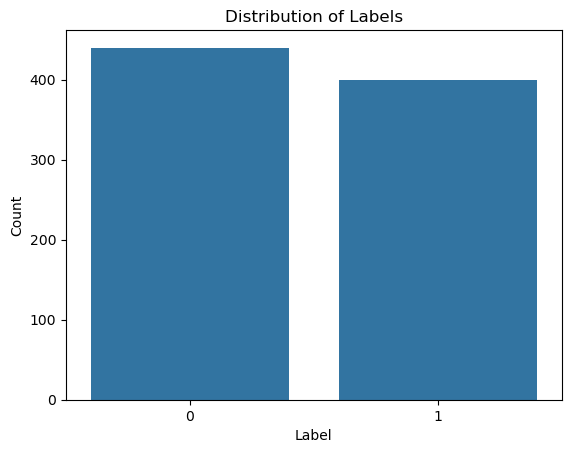

In [31]:
sns.countplot(data=df, x='label')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [32]:
df

,filename,category,label
0,1-100032-A-0.wav,dog,0
1,1-100038-A-14.wav,chirping_birds,0
2,1-100210-A-36.wav,vacuum_cleaner,1
3,1-100210-B-36.wav,vacuum_cleaner,1
8,1-103298-A-9.wav,crow,0
...,...,...,...
1982,5-260875-A-35.wav,washing_machine,1
1983,5-261325-A-9.wav,crow,0
1996,5-263902-A-36.wav,vacuum_cleaner,1
1998,5-61635-A-8.wav,sheep,0


Save this file as processed_metadata

In [33]:
df.to_csv("../datasets/processed/processed_metadata.csv",index_label=False)